<a href="https://colab.research.google.com/github/wajdalkhaldi/Image-Processing/blob/main/lab4/Lab4_Intensity_Transformations_%26Filtering_Spatial_Domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


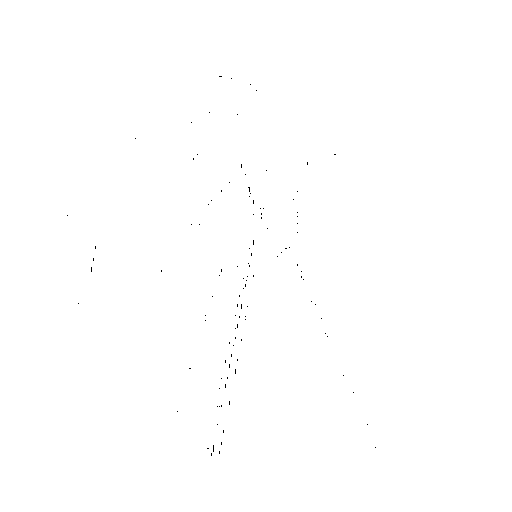

Threshold value: 50


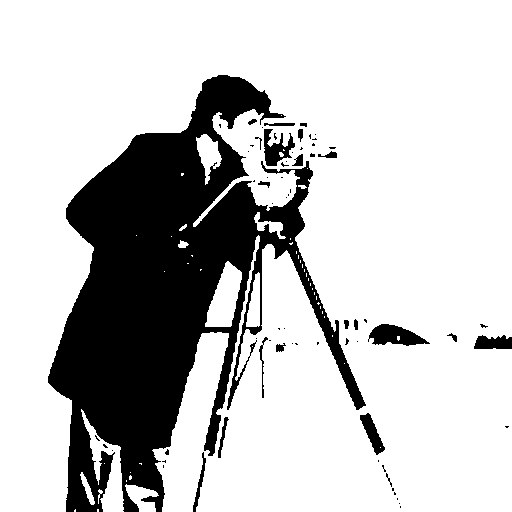

Threshold value: 100


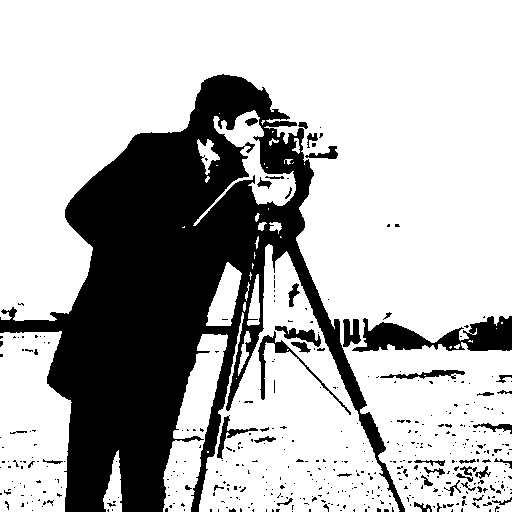

Threshold value: 150


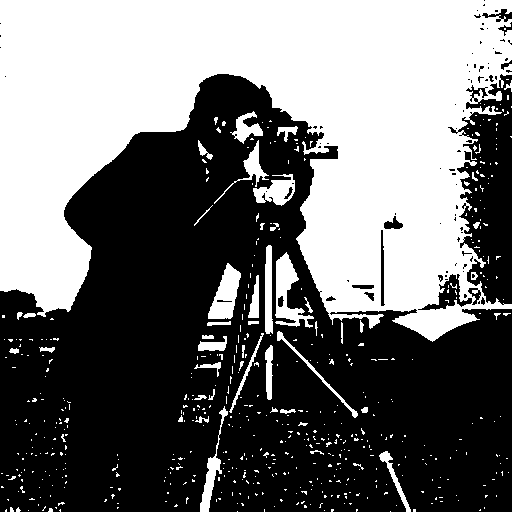

Threshold value: 200


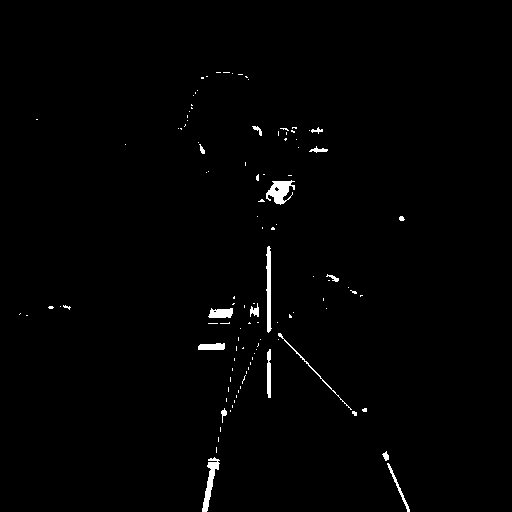

In [5]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY) #each time the value hs compared any thing less than it will be black, any value above it will be white

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


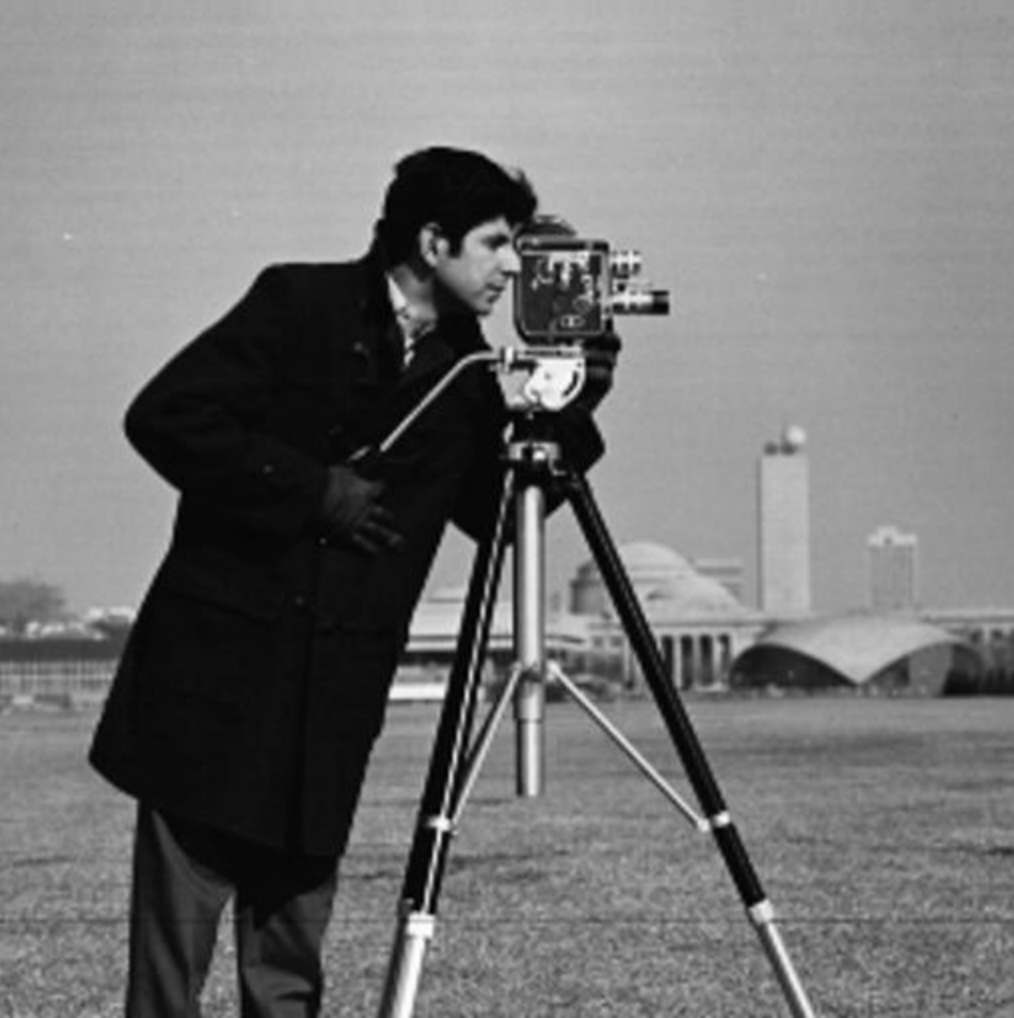

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

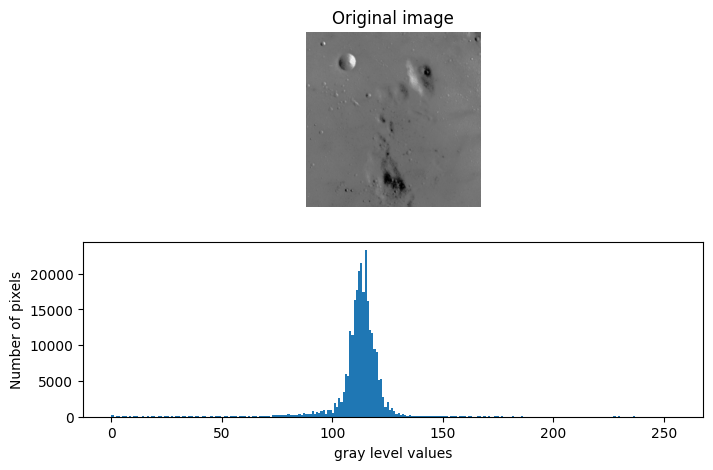

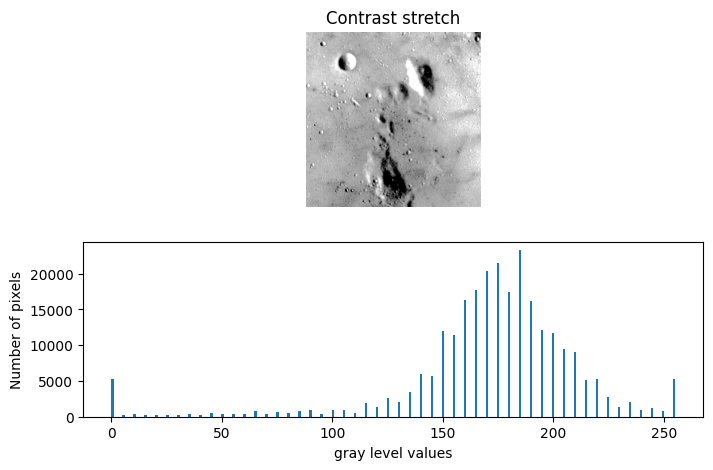

In [8]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np #convert to array and does mathmatical operations

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching convert values to clipped usefull range without outliers the stretching
p2, p98 = np.percentile(img, (2, 98)) #each closed rang shows detailes more
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98)) #does Contrast stretching

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1) #plot of 2 rows and 1 column and pic put in position one
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255)) #plotting the histogram
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


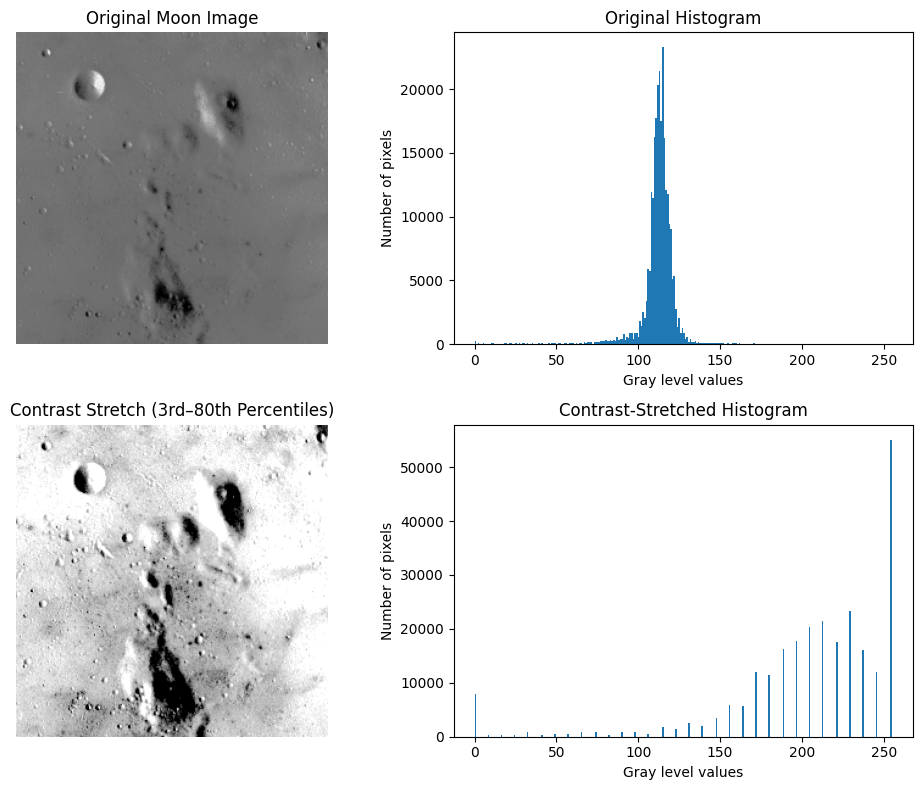

In [9]:
# Task 1: Contrast stretching using the 3rd and 80th percentiles

# Load the moon image
img = data.moon()

# Find the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale the intensity values
img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

# Display the original image and its histogram
fig = plt.figure(figsize=(10, 8))

fig.add_subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Moon Image')

fig.add_subplot(2, 2, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Original Histogram')

# Display the contrast-stretched image and histogram
fig.add_subplot(2, 2, 3)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch (3rd–80th Percentiles)')

fig.add_subplot(2, 2, 4)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Contrast-Stretched Histogram')

plt.tight_layout()
plt.show()

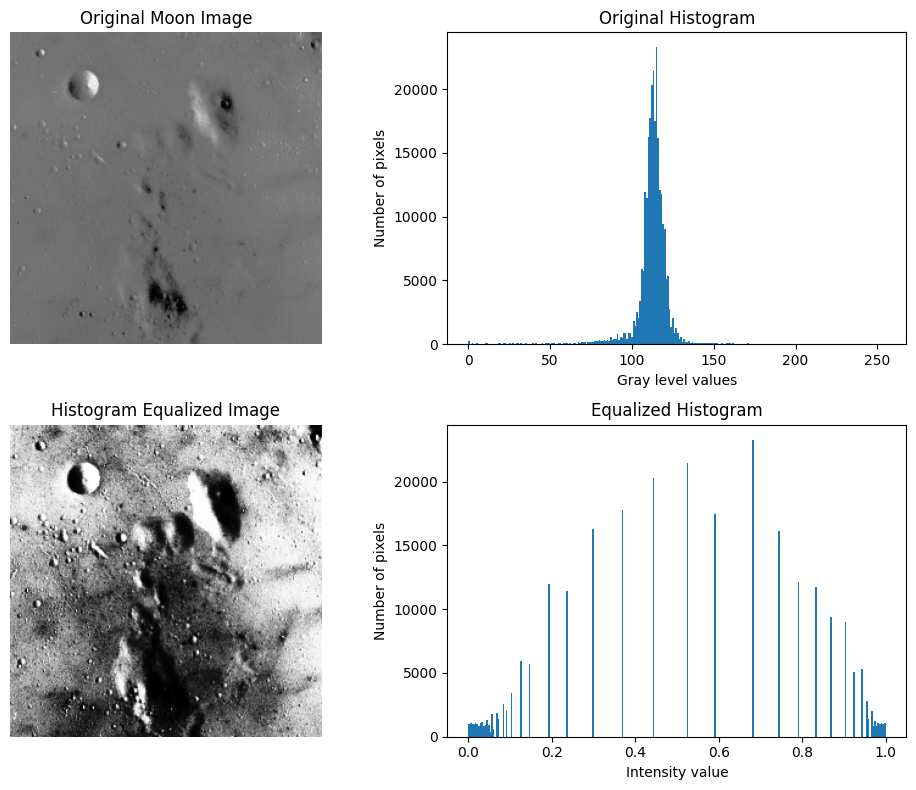

In [10]:
# Task 2: Histogram equalization

# Load the moon image
img = data.moon()

# Apply histogram equalization
img_equalized = exposure.equalize_hist(img)

# Display the equalized image
fig = plt.figure(figsize=(10, 8))

fig.add_subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Moon Image')

# Original histogram
fig.add_subplot(2, 2, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Original Histogram')

# Equalized image
fig.add_subplot(2, 2, 3)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')

# Equalized histogram
fig.add_subplot(2, 2, 4)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('Intensity value')
plt.ylabel('Number of pixels')
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()

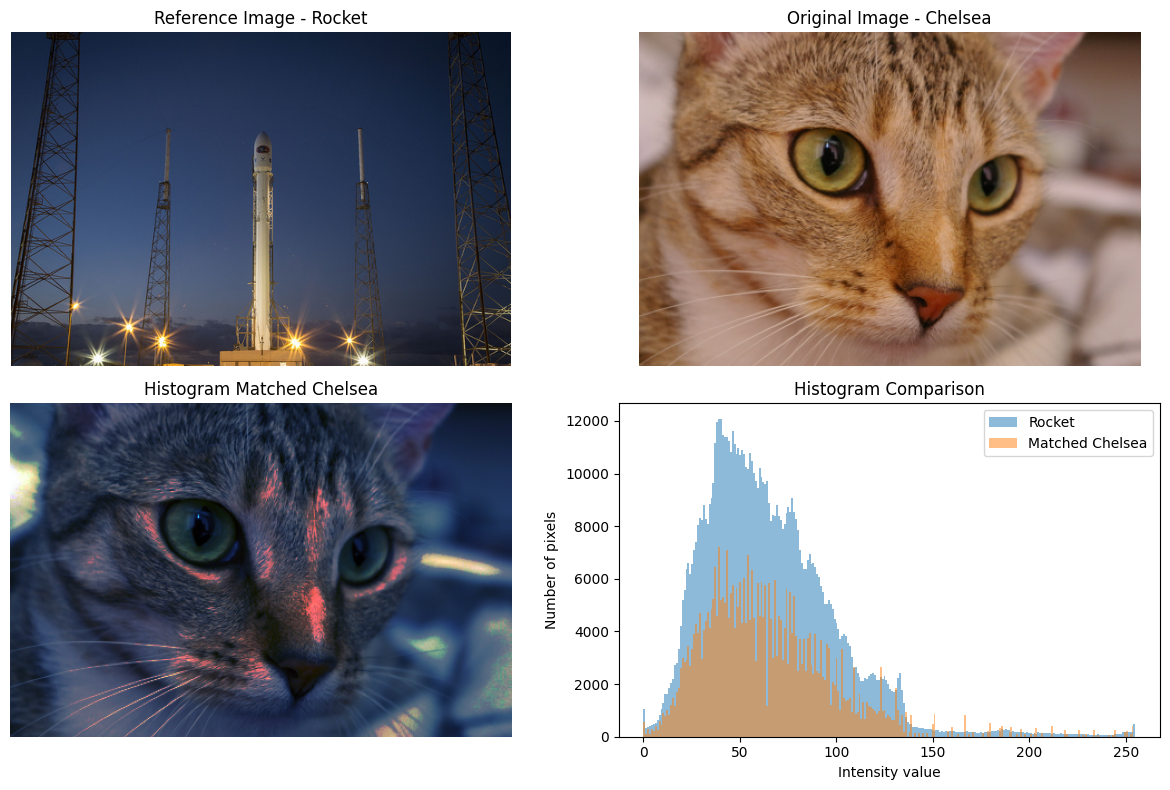

In [11]:
# Task 3: Histogram matching

# Load the reference and target images
reference = data.rocket()
image = data.chelsea()

# Match the histogram of Chelsea to the Rocket image
matched = exposure.match_histograms(image, reference, channel_axis=-1)

# Display the images
fig = plt.figure(figsize=(12, 8))

fig.add_subplot(2, 2, 1)
plt.imshow(reference)
plt.axis('off')
plt.title('Reference Image - Rocket')

fig.add_subplot(2, 2, 2)
plt.imshow(image)
plt.axis('off')
plt.title('Original Image - Chelsea')

fig.add_subplot(2, 2, 3)
plt.imshow(matched)
plt.axis('off')
plt.title('Histogram Matched Chelsea')

# Display histograms
fig.add_subplot(2, 2, 4)

plt.hist(reference.ravel(), bins=256, alpha=0.5, label='Rocket')
plt.hist(matched.ravel(), bins=256, alpha=0.5, label='Matched Chelsea')

plt.xlabel('Intensity value')
plt.ylabel('Number of pixels')
plt.title('Histogram Comparison')
plt.legend()

plt.tight_layout()
plt.show()